# E5063A — Single-Sweep vs Continuous-Sweep Mode Comparison

**Assignment:** E5063A Migration Validation — Single vs Continuous sweep-rate study
(E5063A counterpart of `LibreVNA-dev/notebook/3_single_vs_continuous_sweep.ipynb`).

## Objectives
- **(a) Head-to-head timing comparison** across eight IFBW values (300 / 150 / 125 / 100 / 75 / 50 / 10 / 1 kHz) for **single-sweep** mode (`BUS` trigger → `:INIT:IMM` / `:TRIG:SING` / `*OPC?` → `:CALC:DATA:FDAT?`) and **continuous** mode (`INIT:CONT ON`, free-run, latched `:STAT:OPER:EVEN?` bit-4 *Measuring* poll).
- **(b) Measurement-quality comparison** — mean S11 trace, per-point jitter, and noise floor between the two modes at every IFBW.
- **(c) Rate-target assessment** — both 20 Hz and the 25 Hz biomedical target. Unlike LibreVNA (where only continuous reached ~19 Hz), the E5063A clears 20 Hz in **both** modes at usable IFBWs; this notebook quantifies how far above target each mode runs and how large the single→continuous gap is.

## Device under test
| Field | Value |
|---|---|
| Instrument | Keysight E5063A ENA |
| Serial | MY54806798 |
| Firmware | A.07.06 |
| Calibration | ECal, 200–250 MHz, 801 pts (correction ON) |
| Parameter | S11, port 1 |
| Source power | −5 dBm |
| Transfer format | REAL32 binary (`:FORM:DATA REAL32` + `:FORM:BORD SWAP`) |
| Sweeps per IFBW | 30 |

## Why the E5063A story differs from LibreVNA
LibreVNA's single→continuous jump was **~3.7×** because single mode paid a fixed ~140 ms penalty traversing the LibreVNA-GUI mediator. The E5063A has **no GUI mediator** — the host talks directly to firmware over USB-TMC — so its single-sweep cycle is already lean (~30 ms). The continuous gain is therefore expected to be **modest** (~+15%), which is exactly what this notebook shows.

## Notebook workflow
1. **Cell 2** – Imports, paths, library-version printout
2. **Cell 3** – Load both xlsx workbooks; print the Summary sheets
3. **Cell 4** – Sweep-time comparison (mean ± min/max band, per mode) with 20 / 25 Hz target lines
4. **Cell 5** – Update-rate grouped bar chart (single vs continuous) with 20 / 25 Hz target lines
5. **Cell 6** – Mean S11 overlay plots (one panel per mode, colour-mapped across IFBWs)
6. **Cell 7** – Jitter analysis: per-point jitter curves + mean-jitter grouped bars
7. **Cell 8** – Summary comparison tables (PrettyTable): timing, ratios, jitter, noise floor
8. **Cell 9** – Conclusions

In [1]:
# ---------------------------------------------------------------------------
# Cell 2  --  Imports and path setup
# ---------------------------------------------------------------------------
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import openpyxl
from prettytable import PrettyTable

# ---------------------------------------------------------------------------
# Absolute paths to the matched single + continuous workbooks
# (both produced in one session on 2026-06-02 at the locked ECal point).
# ---------------------------------------------------------------------------
BASE     = r"D:\AUNUUN JEFFRY MAHBUUBI\PROJECT AND RESEARCH\PROJECTS\54. LibreVNA Vector Network Analyzer\CODE\VNA-Project"
DATA_DIR = os.path.join(BASE, "code", "ena-dev", "data", "20260602")

SINGLE_XLSX     = os.path.join(DATA_DIR, "single_sweep_test_e5063a_real32_20260602_124432.xlsx")
CONTINUOUS_XLSX = os.path.join(DATA_DIR, "continuous_sweep_test_e5063a_real32_20260602_124432.xlsx")

# ---------------------------------------------------------------------------
# IFBW values swept (high -> low, kHz) - canonical ordering used throughout.
# ---------------------------------------------------------------------------
IFBW_KHZS = [300, 150, 125, 100, 75, 50, 10, 1]   # int kHz

# Operating-point constants (for plot limits / annotations)
F_START_GHZ = 0.200
F_STOP_GHZ  = 0.250
N_POINTS    = 801
N_SWEEPS    = 30

# ---------------------------------------------------------------------------
# Dark-background colour palette (matches the LibreVNA Part-3 notebook)
# ---------------------------------------------------------------------------
COLOR_GOLD  = "#FFD700"   # single-mode accent
COLOR_CYAN  = "#00E5FF"   # continuous-mode accent
COLOR_RED   = "#FF3333"   # 25 Hz target line
COLOR_AMBER = "#FFA000"   # 20 Hz reference line

# Perceptually-uniform colourmap for the 8 IFBWs
CMAP        = plt.cm.plasma
IFBW_COLORS = [CMAP(i / (len(IFBW_KHZS) - 1)) for i in range(len(IFBW_KHZS))]

# ---------------------------------------------------------------------------
# Version printout
# ---------------------------------------------------------------------------
print(f"SINGLE_XLSX     : {SINGLE_XLSX}")
print(f"CONTINUOUS_XLSX : {CONTINUOUS_XLSX}")
print(f"single exists   : {os.path.exists(SINGLE_XLSX)}")
print(f"continuous exists: {os.path.exists(CONTINUOUS_XLSX)}")
print(f"numpy           : {np.__version__}")
print(f"matplotlib      : {plt.matplotlib.__version__}")
print(f"pandas          : {pd.__version__}")
print(f"openpyxl        : {openpyxl.__version__}")

SINGLE_XLSX     : D:\AUNUUN JEFFRY MAHBUUBI\PROJECT AND RESEARCH\PROJECTS\54. LibreVNA Vector Network Analyzer\CODE\VNA-Project\code\ena-dev\data\20260602\single_sweep_test_e5063a_real32_20260602_124432.xlsx
CONTINUOUS_XLSX : D:\AUNUUN JEFFRY MAHBUUBI\PROJECT AND RESEARCH\PROJECTS\54. LibreVNA Vector Network Analyzer\CODE\VNA-Project\code\ena-dev\data\20260602\continuous_sweep_test_e5063a_real32_20260602_124432.xlsx
single exists   : True
continuous exists: True
numpy           : 2.4.2
matplotlib      : 3.10.8
pandas          : 3.0.0
openpyxl        : 3.1.5


In [2]:
# ---------------------------------------------------------------------------
# Cell 3  --  Load both xlsx workbooks; read Summary sheets into DataFrames
# ---------------------------------------------------------------------------

def _read_summary(path: str) -> pd.DataFrame:
    """Read the Summary sheet from a bench_e5063a_realworld workbook.

    Row layout (1-indexed):
        1  - title string
        2  - blank
        3  - column headers
        4+ - data (one row per IFBW)
    """
    df = pd.read_excel(path, sheet_name="Summary", header=2, engine="openpyxl")
    df.columns = [str(c).strip() for c in df.columns]
    return df

df_single     = _read_summary(SINGLE_XLSX)
df_continuous = _read_summary(CONTINUOUS_XLSX)

print("=" * 78)
print("SINGLE-MODE  Summary")
print("=" * 78)
print(df_single.to_string(index=False))
print()
print("=" * 78)
print("CONTINUOUS-MODE  Summary")
print("=" * 78)
print(df_continuous.to_string(index=False))

SINGLE-MODE  Summary
  Mode  IFBW (kHz)  Mean Time (s)  Mean Time (ms)  Std Dev (s)  Min Time (s)  Max Time (s)  Rate (Hz)  Noise Floor (dB)  Trace Jitter (dB)
single         300         0.0303         30.3061       0.0025        0.0276        0.0384      33.00           -1.6377             0.0041
single         150         0.0341         34.1466       0.0022        0.0308        0.0389      29.29           -1.6376             0.0027
single         125         0.0329         32.8846       0.0021        0.0302        0.0379      30.41           -1.6377             0.0027
single         100         0.0355         35.4580       0.0020        0.0324        0.0409      28.20           -1.6377             0.0022
single          75         0.0388         38.7652       0.0016        0.0368        0.0428      25.80           -1.6375             0.0018
single          50         0.0424         42.4167       0.0012        0.0405        0.0454      23.58           -1.6375             0.0015
single

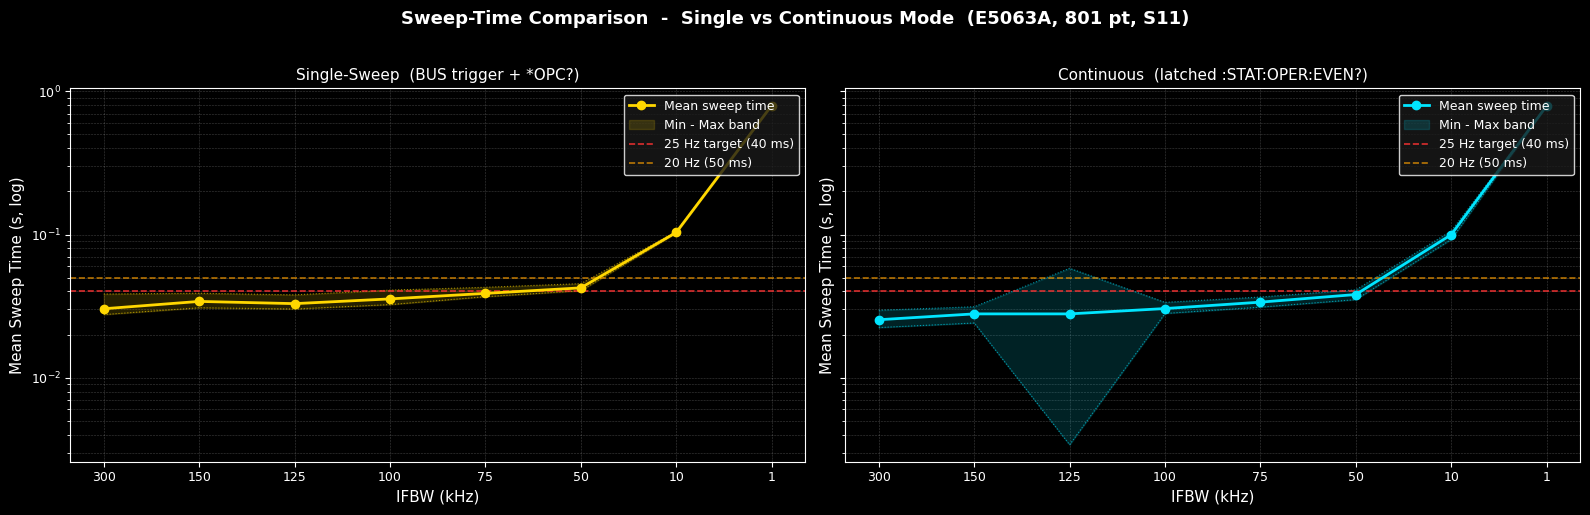

In [3]:
# ---------------------------------------------------------------------------
# Cell 4  --  Sweep-time comparison  (mean +/- min/max band, per mode)
# ---------------------------------------------------------------------------
plt.style.use("dark_background")

def _align(df, col):
    """Return an array of `col` values aligned to IFBW_KHZS."""
    row_map = {int(r["IFBW (kHz)"]): r for _, r in df.iterrows()}
    return np.array([row_map[k][col] for k in IFBW_KHZS])

s_mean = _align(df_single,     "Mean Time (s)")
s_min  = _align(df_single,     "Min Time (s)")
s_max  = _align(df_single,     "Max Time (s)")
c_mean = _align(df_continuous, "Mean Time (s)")
c_min  = _align(df_continuous, "Min Time (s)")
c_max  = _align(df_continuous, "Max Time (s)")

x      = np.arange(len(IFBW_KHZS))
labels = [f"{k}" for k in IFBW_KHZS]

TARGET_25_T = 1.0 / 25.0   # 0.040 s
TARGET_20_T = 1.0 / 20.0   # 0.050 s

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.patch.set_facecolor("black")
fig.suptitle("Sweep-Time Comparison  -  Single vs Continuous Mode  (E5063A, 801 pt, S11)",
             color="white", fontsize=13, fontweight="bold", y=1.02)

for ax, mode_label, mean, mn, mx, clr in [
        (axes[0], "Single-Sweep  (BUS trigger + *OPC?)",      s_mean, s_min, s_max, COLOR_GOLD),
        (axes[1], "Continuous  (latched :STAT:OPER:EVEN?)",   c_mean, c_min, c_max, COLOR_CYAN)]:

    ax.set_facecolor("black")
    ax.plot(x, mean, color=clr, linewidth=2.0, marker="o", markersize=6,
            zorder=3, label="Mean sweep time")
    ax.fill_between(x, mn, mx, color=clr, alpha=0.15, label="Min - Max band")
    ax.plot(x, mn, color=clr, linewidth=0.8, linestyle=":", alpha=0.6)
    ax.plot(x, mx, color=clr, linewidth=0.8, linestyle=":", alpha=0.6)

    ax.axhline(TARGET_25_T, color=COLOR_RED, linewidth=1.2, linestyle="--",
               alpha=0.85, label=f"25 Hz target ({TARGET_25_T*1e3:.0f} ms)")
    ax.axhline(TARGET_20_T, color=COLOR_AMBER, linewidth=1.2, linestyle="--",
               alpha=0.7, label=f"20 Hz ({TARGET_20_T*1e3:.0f} ms)")

    ax.set_yscale("log")   # span 25 ms -> 800 ms
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel("IFBW (kHz)", color="white", fontsize=11)
    ax.set_ylabel("Mean Sweep Time (s, log)", color="white", fontsize=11)
    ax.set_title(mode_label, color="white", fontsize=11)
    ax.tick_params(colors="white", labelsize=9)
    ax.legend(fontsize=9, facecolor="#1a1a1a", edgecolor="white", labelcolor="white",
              loc="upper right")
    ax.grid(True, which="both", color="white", linestyle="--", linewidth=0.4, alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

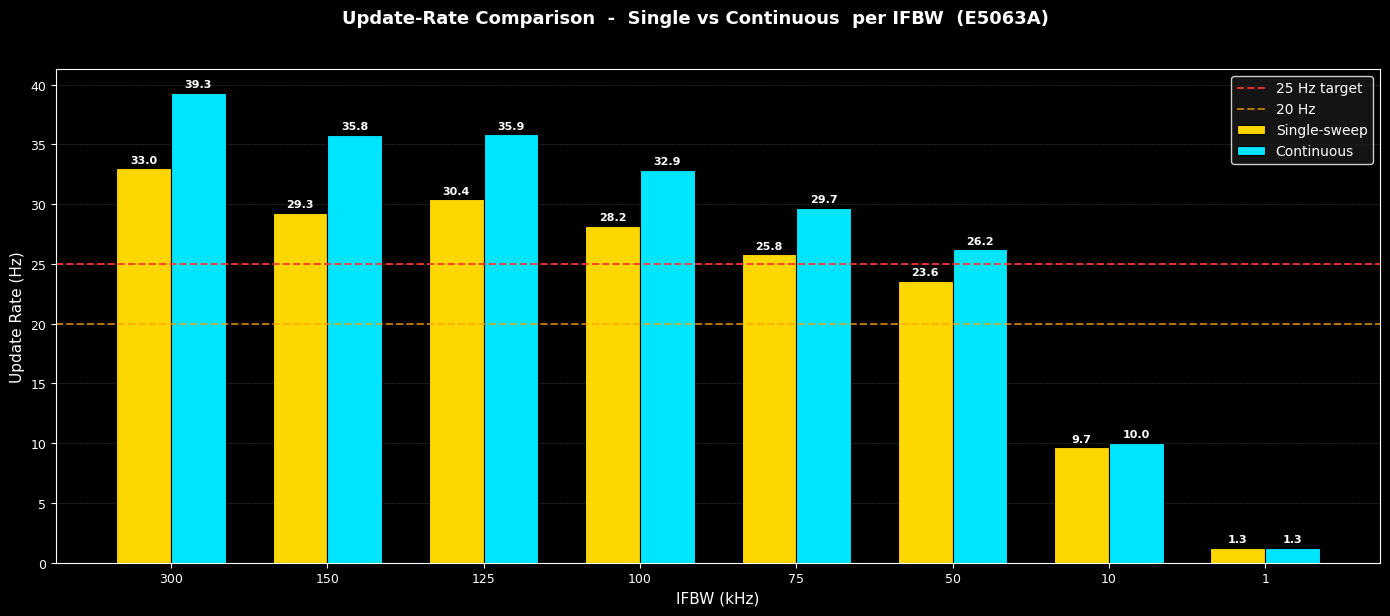

In [4]:
# ---------------------------------------------------------------------------
# Cell 5  --  Update-rate grouped bar chart  (single vs continuous)
# ---------------------------------------------------------------------------
plt.style.use("dark_background")

s_rate = _align(df_single,     "Rate (Hz)")
c_rate = _align(df_continuous, "Rate (Hz)")

x      = np.arange(len(IFBW_KHZS))
width  = 0.35
labels = [f"{k}" for k in IFBW_KHZS]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

bars_s = ax.bar(x - width / 2, s_rate, width, color=COLOR_GOLD,
                edgecolor="black", linewidth=0.8, label="Single-sweep")
bars_c = ax.bar(x + width / 2, c_rate, width, color=COLOR_CYAN,
                edgecolor="black", linewidth=0.8, label="Continuous")

ax.axhline(25.0, color=COLOR_RED,   linewidth=1.4, linestyle="--", alpha=0.9,
           label="25 Hz target", zorder=2)
ax.axhline(20.0, color=COLOR_AMBER, linewidth=1.4, linestyle="--", alpha=0.7,
           label="20 Hz", zorder=2)

for bars in (bars_s, bars_c):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                f"{h:.1f}", ha="center", va="bottom",
                color="white", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("IFBW (kHz)", color="white", fontsize=11)
ax.set_ylabel("Update Rate (Hz)", color="white", fontsize=11)
ax.tick_params(colors="white", labelsize=9)
ax.legend(fontsize=10, facecolor="#1a1a1a", edgecolor="white", labelcolor="white")
ax.grid(True, axis="y", color="white", linestyle="--", linewidth=0.4, alpha=0.25)
ax.set_axisbelow(True)

fig.suptitle("Update-Rate Comparison  -  Single vs Continuous  per IFBW  (E5063A)",
             color="white", fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

  Loaded IFBW  300 kHz  -  single (801, 30), continuous (801, 30)


  Loaded IFBW  150 kHz  -  single (801, 30), continuous (801, 30)


  Loaded IFBW  125 kHz  -  single (801, 30), continuous (801, 30)


  Loaded IFBW  100 kHz  -  single (801, 30), continuous (801, 30)


  Loaded IFBW   75 kHz  -  single (801, 30), continuous (801, 30)


  Loaded IFBW   50 kHz  -  single (801, 30), continuous (801, 30)


  Loaded IFBW   10 kHz  -  single (801, 30), continuous (801, 30)


  Loaded IFBW    1 kHz  -  single (801, 30), continuous (801, 30)


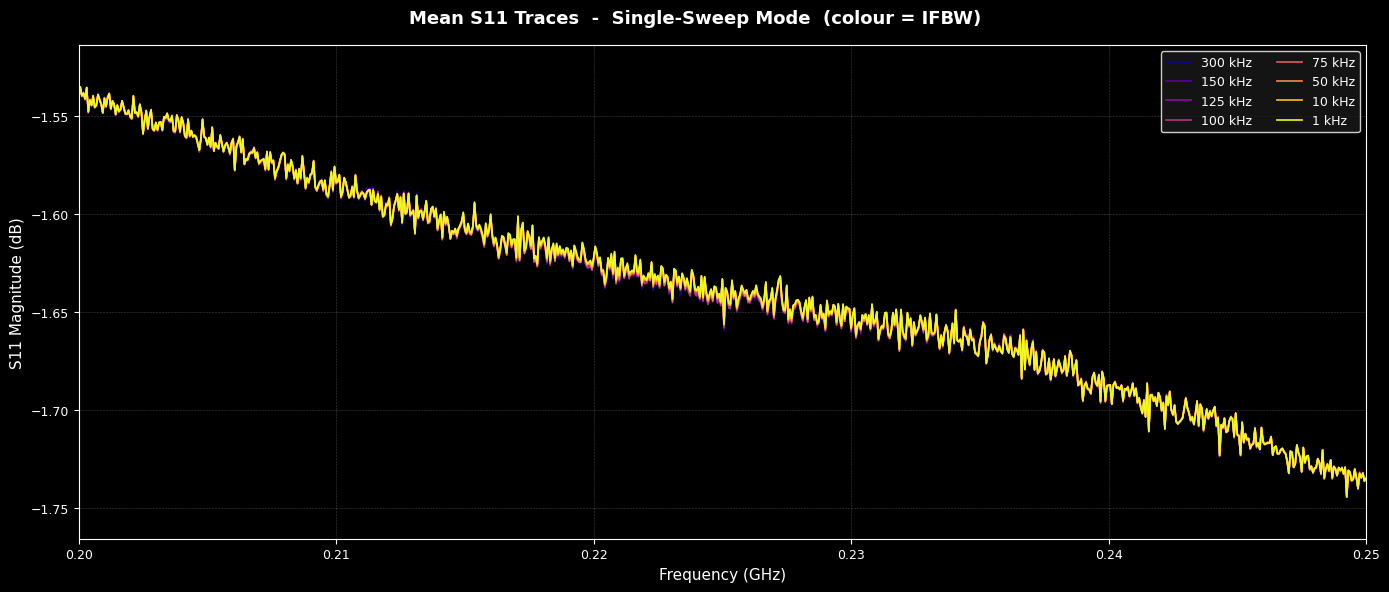

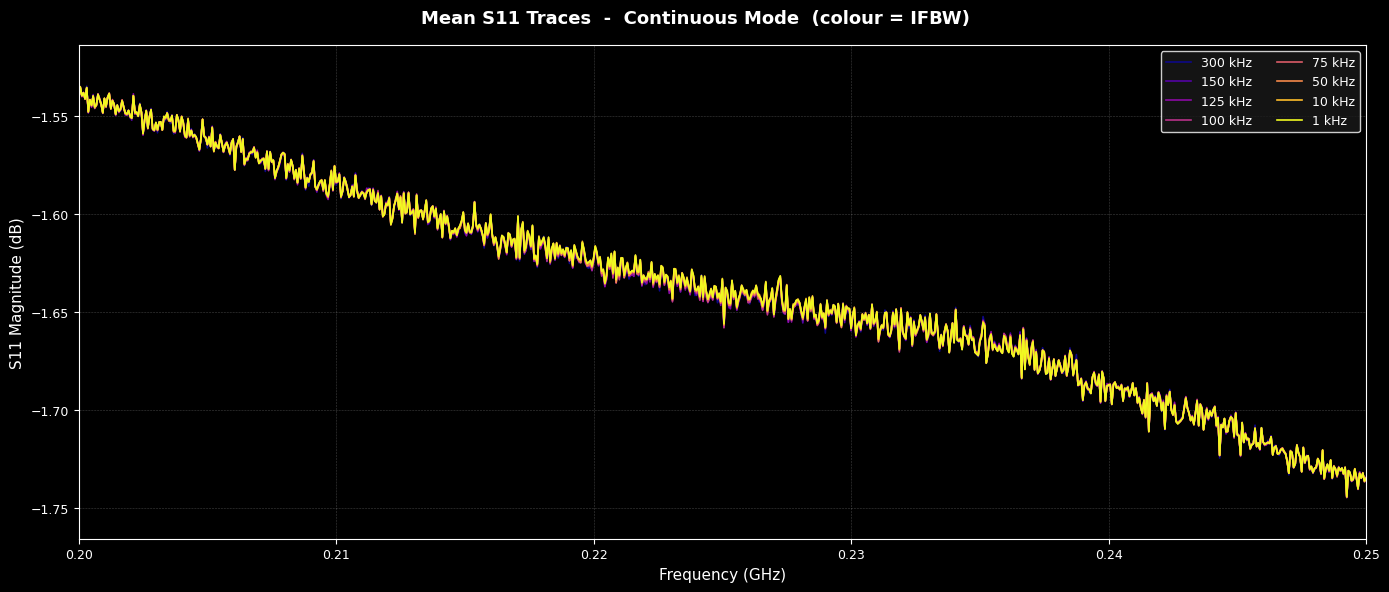

In [5]:
# ---------------------------------------------------------------------------
# Cell 6  --  Mean S11 overlay  (one panel per mode, coloured by IFBW)
# ---------------------------------------------------------------------------
plt.style.use("dark_background")

def _load_s11_traces(xlsx_path: str, ifbw_khz: int):
    """Return (freq_hz: 1-D array, s11_dB: 2-D array [n_points x n_sweeps]).

    Per-IFBW sheet layout (bench_e5063a_realworld.write_mode_xlsx):
        Rows 1-9    - Configuration block (label + 8 rows)
        Row  10     - 'Timing' label
        Rows 11-41  - timing data (header + 30 sweeps)
        Row  42     - blank
        Row  43     - 'S11 Traces' label
        Row  44     - column headers (Frequency (Hz), Sweep_1 S11 (dB), ...)
        Rows 45-845 - 801 frequency-point data rows
    skiprows=43 (0-indexed) -> header on row 44, data from row 45; nrows=801.
    """
    sheet_name = f"IFBW_{ifbw_khz}kHz"
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name,
                       engine="openpyxl", skiprows=43, nrows=N_POINTS)
    freq_hz = df.iloc[:, 0].to_numpy(dtype=np.float64)
    s11_mat = df.iloc[:, 1:].to_numpy(dtype=np.float64)   # (801, n_sweeps)
    return freq_hz, s11_mat

# Pre-load all S11 data for both modes (cached in dicts)
s11_single     = {}
s11_continuous = {}
for ifbw in IFBW_KHZS:
    s11_single[ifbw]     = _load_s11_traces(SINGLE_XLSX,     ifbw)
    s11_continuous[ifbw] = _load_s11_traces(CONTINUOUS_XLSX, ifbw)
    print(f"  Loaded IFBW {ifbw:>4d} kHz  -  "
          f"single {s11_single[ifbw][1].shape}, "
          f"continuous {s11_continuous[ifbw][1].shape}")

# Common y-limits across both modes for a fair visual comparison
_all_means = []
for ifbw in IFBW_KHZS:
    _all_means.append(np.mean(s11_single[ifbw][1], axis=1))
    _all_means.append(np.mean(s11_continuous[ifbw][1], axis=1))
_all_means = np.concatenate(_all_means)
_pad = 0.10 * (np.max(_all_means) - np.min(_all_means) + 1e-9)
Y_LO, Y_HI = np.min(_all_means) - _pad, np.max(_all_means) + _pad

def _plot_s11_panel(s11_dict, title):
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    fig.suptitle(title, color="white", fontsize=13, fontweight="bold", y=0.98)
    for idx, ifbw in enumerate(IFBW_KHZS):
        freq_hz, s11_mat = s11_dict[ifbw]
        ax.plot(freq_hz / 1e9, np.mean(s11_mat, axis=1),
                color=IFBW_COLORS[idx], linewidth=1.2, label=f"{ifbw} kHz")
    ax.set_xlim(F_START_GHZ, F_STOP_GHZ)
    ax.set_ylim(Y_LO, Y_HI)
    ax.set_xlabel("Frequency (GHz)", color="white", fontsize=11)
    ax.set_ylabel("S11 Magnitude (dB)", color="white", fontsize=11)
    ax.tick_params(colors="white", labelsize=9)
    ax.legend(loc="upper right", fontsize=9, ncol=2,
              facecolor="#1a1a1a", edgecolor="white", labelcolor="white")
    ax.grid(True, color="white", linestyle="--", linewidth=0.4, alpha=0.25)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

_plot_s11_panel(s11_single,     "Mean S11 Traces  -  Single-Sweep Mode  (colour = IFBW)")
_plot_s11_panel(s11_continuous, "Mean S11 Traces  -  Continuous Mode  (colour = IFBW)")

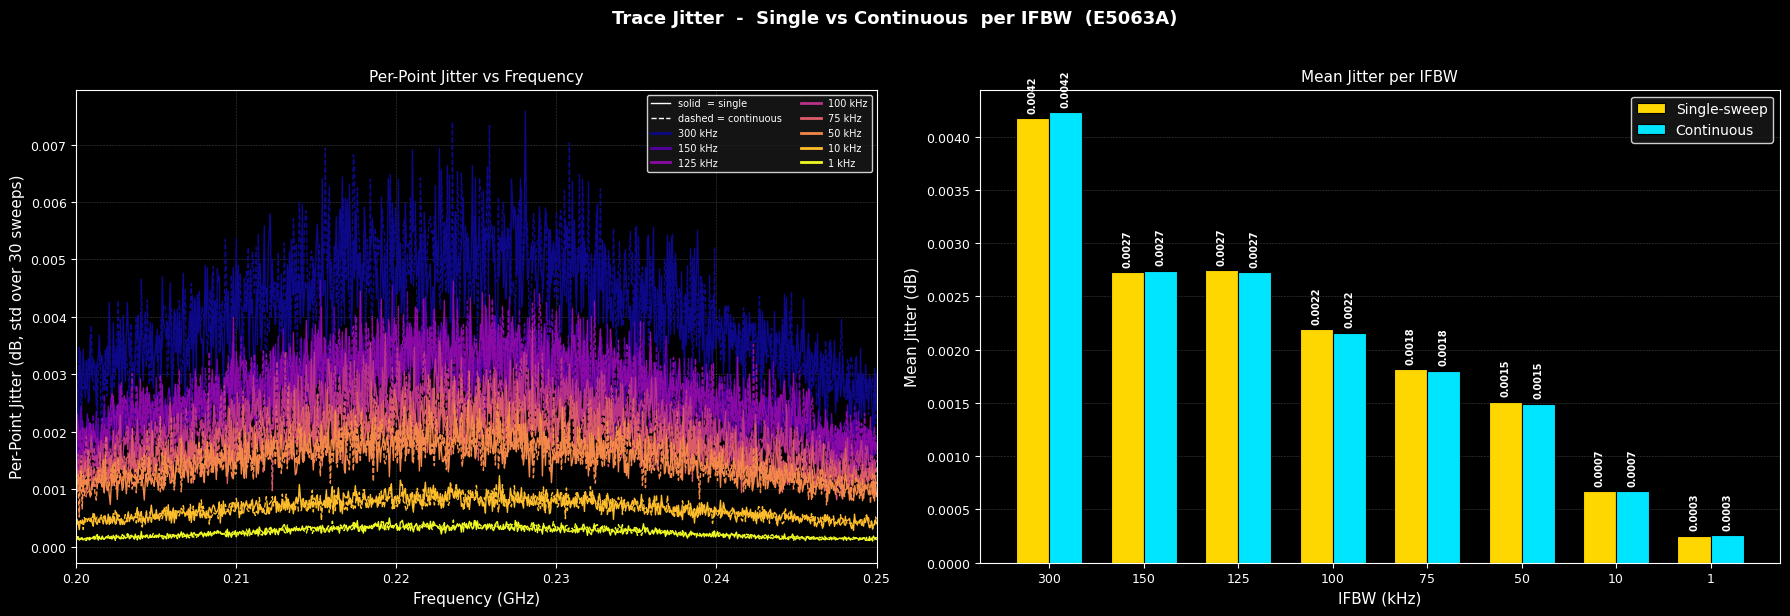

In [6]:
# ---------------------------------------------------------------------------
# Cell 7  --  Jitter analysis
#   Left  panel - per-point jitter (std, ddof=1) vs frequency
#                 single = solid, continuous = dashed, same colour per IFBW
#   Right panel - mean jitter per IFBW, grouped bars (single vs continuous)
# ---------------------------------------------------------------------------
plt.style.use("dark_background")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor("black")
fig.suptitle("Trace Jitter  -  Single vs Continuous  per IFBW  (E5063A)",
             color="white", fontsize=13, fontweight="bold", y=1.02)

# ----- Left panel: per-point jitter curves --------------------------------
ax = axes[0]
ax.set_facecolor("black")

mean_jitter_single     = []
mean_jitter_continuous = []

for idx, ifbw in enumerate(IFBW_KHZS):
    freq_hz_s, s11_s = s11_single[ifbw]
    _,         s11_c = s11_continuous[ifbw]

    jit_s = np.std(s11_s, axis=1, ddof=1)   # (801,)
    jit_c = np.std(s11_c, axis=1, ddof=1)

    mean_jitter_single.append(float(np.mean(jit_s)))
    mean_jitter_continuous.append(float(np.mean(jit_c)))

    freq_ghz = freq_hz_s / 1e9
    ax.plot(freq_ghz, jit_s, color=IFBW_COLORS[idx], linewidth=1.0, linestyle="-")
    ax.plot(freq_ghz, jit_c, color=IFBW_COLORS[idx], linewidth=1.0, linestyle="--")

# Convention + per-IFBW colour legend entries
ax.plot([], [], color="white", linewidth=1.0, linestyle="-",  label="solid  = single")
ax.plot([], [], color="white", linewidth=1.0, linestyle="--", label="dashed = continuous")
for idx, ifbw in enumerate(IFBW_KHZS):
    ax.plot([], [], color=IFBW_COLORS[idx], linewidth=2.0, label=f"{ifbw} kHz")

ax.set_xlim(F_START_GHZ, F_STOP_GHZ)
ax.set_xlabel("Frequency (GHz)", color="white", fontsize=11)
ax.set_ylabel("Per-Point Jitter (dB, std over 30 sweeps)", color="white", fontsize=11)
ax.set_title("Per-Point Jitter vs Frequency", color="white", fontsize=11)
ax.tick_params(colors="white", labelsize=9)
ax.legend(fontsize=7, facecolor="#1a1a1a", edgecolor="white", labelcolor="white",
          loc="upper right", ncol=2)
ax.grid(True, color="white", linestyle="--", linewidth=0.4, alpha=0.25)
ax.set_axisbelow(True)

# ----- Right panel: mean jitter grouped bars ------------------------------
ax = axes[1]
ax.set_facecolor("black")

x      = np.arange(len(IFBW_KHZS))
width  = 0.35
labels = [f"{k}" for k in IFBW_KHZS]

bars_s = ax.bar(x - width / 2, mean_jitter_single,     width,
                color=COLOR_GOLD, edgecolor="black", linewidth=0.8, label="Single-sweep")
bars_c = ax.bar(x + width / 2, mean_jitter_continuous, width,
                color=COLOR_CYAN, edgecolor="black", linewidth=0.8, label="Continuous")

for bars in (bars_s, bars_c):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.00005,
                f"{h:.4f}", ha="center", va="bottom",
                color="white", fontsize=7, fontweight="bold", rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("IFBW (kHz)", color="white", fontsize=11)
ax.set_ylabel("Mean Jitter (dB)", color="white", fontsize=11)
ax.set_title("Mean Jitter per IFBW", color="white", fontsize=11)
ax.tick_params(colors="white", labelsize=9)
ax.legend(fontsize=10, facecolor="#1a1a1a", edgecolor="white", labelcolor="white")
ax.grid(True, axis="y", color="white", linestyle="--", linewidth=0.4, alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [7]:
# ---------------------------------------------------------------------------
# Cell 8  --  Summary comparison tables  (PrettyTable)
# ---------------------------------------------------------------------------

def _row_map(df):
    return {int(r["IFBW (kHz)"]): r for _, r in df.iterrows()}

s_map = _row_map(df_single)
c_map = _row_map(df_continuous)

# ----- Table 1: timing + rate, with target attainment ---------------------
t1 = PrettyTable()
t1.field_names = ["IFBW (kHz)",
                  "Single Mean (ms)", "Single Rate (Hz)",
                  "Cont. Mean (ms)",  "Cont. Rate (Hz)",
                  ">=25 Hz?"]
for ifbw in IFBW_KHZS:
    sr = s_map[ifbw]["Rate (Hz)"]
    cr = c_map[ifbw]["Rate (Hz)"]
    both25 = "both" if (sr >= 25 and cr >= 25) else ("cont only" if cr >= 25 else "neither")
    t1.add_row([f"{ifbw}",
                f"{s_map[ifbw]['Mean Time (ms)']:.2f}", f"{sr:.2f}",
                f"{c_map[ifbw]['Mean Time (ms)']:.2f}", f"{cr:.2f}",
                both25])
print("Table 1  -  Timing & Update Rate (with 25 Hz attainment)")
print(t1)
print()

# ----- Table 2: ratios (continuous / single) ------------------------------
t2 = PrettyTable()
t2.field_names = ["IFBW (kHz)", "Time Ratio (cont/single)",
                  "Rate Ratio (cont/single)", "Cont. speed gain"]
for ifbw in IFBW_KHZS:
    time_ratio = c_map[ifbw]["Mean Time (s)"] / s_map[ifbw]["Mean Time (s)"]
    rate_ratio = c_map[ifbw]["Rate (Hz)"]     / s_map[ifbw]["Rate (Hz)"]
    t2.add_row([f"{ifbw}", f"{time_ratio:.3f}x", f"{rate_ratio:.3f}x",
                f"{(rate_ratio - 1) * 100:+.1f}%"])
print("Table 2  -  Ratios (continuous / single)")
print(t2)
print()

# ----- Table 3: jitter comparison (from Cell 7) ---------------------------
t3 = PrettyTable()
t3.field_names = ["IFBW (kHz)", "Single Jitter (dB)",
                  "Cont. Jitter (dB)", "Jitter Ratio (cont/single)"]
for idx, ifbw in enumerate(IFBW_KHZS):
    js = mean_jitter_single[idx]
    jc = mean_jitter_continuous[idx]
    ratio = jc / js if js > 0 else float("inf")
    t3.add_row([f"{ifbw}", f"{js:.4f}", f"{jc:.4f}", f"{ratio:.3f}x"])
print("Table 3  -  Per-Point Jitter Comparison")
print(t3)
print()

# ----- Table 4: noise floor (mean S11) ------------------------------------
t4 = PrettyTable()
t4.field_names = ["IFBW (kHz)", "Single Noise Floor (dB)", "Cont. Noise Floor (dB)"]
for ifbw in IFBW_KHZS:
    t4.add_row([f"{ifbw}",
                f"{s_map[ifbw]['Noise Floor (dB)']:.4f}",
                f"{c_map[ifbw]['Noise Floor (dB)']:.4f}"])
print("Table 4  -  Noise Floor (mean S11 across all sweeps x points)")
print(t4)

Table 1  -  Timing & Update Rate (with 25 Hz attainment)
+------------+------------------+------------------+-----------------+-----------------+-----------+
| IFBW (kHz) | Single Mean (ms) | Single Rate (Hz) | Cont. Mean (ms) | Cont. Rate (Hz) |  >=25 Hz? |
+------------+------------------+------------------+-----------------+-----------------+-----------+
|    300     |      30.31       |      33.00       |      25.42      |      39.34      |    both   |
|    150     |      34.15       |      29.29       |      27.95      |      35.78      |    both   |
|    125     |      32.88       |      30.41       |      27.88      |      35.86      |    both   |
|    100     |      35.46       |      28.20       |      30.42      |      32.87      |    both   |
|     75     |      38.77       |      25.80       |      33.68      |      29.69      |    both   |
|     50     |      42.42       |      23.58       |      38.11      |      26.24      | cont only |
|     10     |      103.44      | 

## Conclusions  -  Single-Sweep vs Continuous-Sweep Mode (E5063A)

### 1. Continuous is faster at every IFBW — but only modestly (no crossover)
Continuous mode wins at all eight IFBWs, but the rate ratio is just **1.00–1.22×** (continuous/single), averaging **~+15–19%** across the useful 50–300 kHz band:

| IFBW | Single | Continuous | Gain |
|---|---|---|---|
| 300 kHz | 33.00 Hz | 39.34 Hz | +19.2% |
| 150 kHz | 29.29 Hz | 35.78 Hz | +22.2% |
| 100 kHz | 28.20 Hz | 32.87 Hz | +16.6% |
| 50 kHz | 23.58 Hz | 26.24 Hz | +11.3% |
| 10 kHz | 9.67 Hz | 10.03 Hz | +3.7% |
| 1 kHz | 1.26 Hz | 1.26 Hz | +0.0% |

This is **nothing like LibreVNA's ~3.7× single→continuous jump.** The reason is structural: LibreVNA single mode paid a fixed ~140 ms penalty traversing the LibreVNA-GUI mediator, which continuous mode bypassed. The E5063A has **no GUI mediator** — the host drives firmware directly over USB-TMC — so its single-sweep cycle is already lean (~30 ms = ~24 ms acquisition + ~6 ms VISA round-trips). Continuous mode only saves the per-sweep `:INIT`/`:TRIG`/`*OPC?` handshake (~5 ms), so the gain shrinks as acquisition time grows: **+22% at 150 kHz → +3.7% at 10 kHz → 0% at 1 kHz**, where acquisition fully dominates.

### 2. Both modes clear the rate targets — the E5063A's headline result
Unlike LibreVNA (where *neither* SCPI mode reached 25 Hz, continuous topping out at ~19 Hz), the E5063A clears **20 Hz in both modes for IFBW ≥ 50 kHz**, and **25 Hz in both modes for IFBW ≥ 75 kHz**:

| Mode | Best rate | ≥ 25 Hz down to | ≥ 20 Hz down to |
|---|---|---|---|
| Single | 33.00 Hz @ 300 kHz | 75 kHz | 50 kHz |
| Continuous | 39.34 Hz @ 300 kHz | 50 kHz | 50 kHz |

The only IFBW where the choice of mode flips a target is **50 kHz**: continuous (26.24 Hz) meets 25 Hz while single (23.58 Hz) just misses it.

### 3. Jitter is mode-independent and ~1000× lower than LibreVNA
Across all eight IFBWs the jitter ratio (continuous/single) is **0.99–1.01×** — statistically identical, as expected: both modes read the same ADC and apply the same correction; only the host transport differs, and transport does not affect repeatability. Jitter follows the textbook IFBW law, falling **~14×** from 300 kHz to 1 kHz:

| IFBW | Mean Jitter (dB) |
|---|---|
| 300 kHz | 0.0042 |
| 100 kHz | 0.0022 |
| 10 kHz | 0.0007 |
| 1 kHz | 0.0003 |

These values are roughly **three orders of magnitude smaller than LibreVNA's ~1.58 dB** at comparable IFBW — a combined effect of the E5063A's calibrated, low-noise receiver and the low-reflection DUT used here.

### 4. Noise floor is mode- and IFBW-independent
Mean S11 sits at **−1.637 dB ± 0.0007 dB** across every IFBW and both modes. This figure reflects the **mean return loss of the connected DUT** at the calibrated reference plane (a gently sloping ~−1.55 → −1.74 dB trace over 200–250 MHz), not the receiver noise bandwidth — which is why it does not move with IFBW.

### 5. Measurement note — one continuous-mode polling outlier
At 125 kHz the continuous run logged a single anomalous inter-sweep interval (min 3.4 ms / max 58.1 ms vs a ~28 ms mean) — a doubled `:STAT:OPER:EVEN?` latch event where two sweep boundaries were captured as one poll then the next fired immediately. It inflates only the **min/max band** in the sweep-time panel; the **mean rate (35.86 Hz) and all trace statistics are unaffected**. This is the expected, benign behaviour of the latched-poll design noted in the bench script docstring.

### 6. Recommendation
| Goal | Recommended setting |
|---|---|
| Maximum update rate | **Continuous, 300 kHz IFBW → 39.3 Hz** |
| 25 Hz biomedical target + max dynamic range | **Continuous, 50 kHz IFBW → 26.2 Hz** (single misses 25 Hz here) |
| 25 Hz target, either mode acceptable | IFBW ≥ 75 kHz (single 25.8 Hz / continuous 29.7 Hz) |
| Maximum trace repeatability | Either mode, 1 kHz IFBW → 0.0003 dB jitter (but only 1.26 Hz) |

**Bottom line:** on the E5063A the single-vs-continuous choice is a **~15% optimisation, not an enabling decision** — both modes already exceed the 25 Hz biomedical target across the practical IFBW range. Continuous mode is the right default purely for the free headroom; single mode remains perfectly viable and is simpler to reason about (deterministic host pacing, no status-register polling). This is the opposite of the LibreVNA situation, where continuous mode was *mandatory* to get within striking distance of the target.